**# AlexNet on CIFAR-10**



### ALL the importation

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision

import torch.nn as nn
from mpmath.identification import transforms
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader, SubsetRandomSampler

# Settings and Dataset

In [3]:
# --- hyperparamètres ---
RANDOM_SEED = 123
BATCH_SIZE = 256
NUM_EPOCHES = 200
NUM_CLASSES = 3
LEARING_RATE = 0.0005
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((70, 70)),
    transforms.RandomCrop((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                                      ])

test_transforms = transforms.Compose([
    transforms.Resize((70, 70)),
    transforms.CenterCrop((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

#Load datasets
trainset = torchvision.datasets.CIFAR10(root='./data',
                                        train=True,
                                        download=True,
                                        transform=train_transforms)

testset = (torchvision.datasets.CIFAR10(root='./data',
                                        train=False,
                                        download=True,
                                        transform=test_transforms))

#create dataLoaders
trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=4,
                                          shuffle=True,
                                          num_workers=0)

testloader = torch.utils.data.DataLoader(testset,
                                         batch_size=4,
                                         shuffle=False,
                                         num_workers=0)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

for images, labels in trainloader:
    print(f'Image batch dimensions: {images.shape}')
    print(f'Image label dimensions: {labels.shape}')
    print(f'Class labels of 10 examples: {labels[:10]}')
    break

C:\Users\flofl\PycharmProjects\KaczmarzFL\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Image batch dimensions: torch.Size([4, 3, 64, 64])
Image label dimensions: torch.Size([4])
Class labels of 10 examples: tensor([2, 2, 0, 4])


Images affichées:


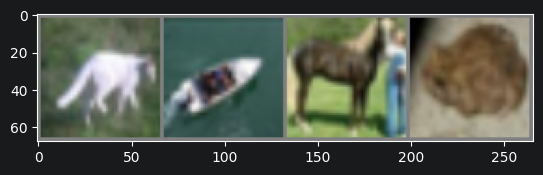

  cat  ship horse  frog


In [5]:
# Fonction pour afficher une image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.cpu().numpy()  # Ajouté .cpu() pour gérer GPU
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
print("Images affichées:")
imshow(torchvision.utils.make_grid(images))
print(' '.join('%5s' % classes[labels[j]] for j in range(min(4, len(labels)))))


# Model Creation



In [6]:
class AlexNet(nn.Module):
    def __init__(self, num_classes):
        self.features = nn.Sequential(
            #--feature extration--
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            #convulotional bloc
            nn.Conv2d(64,192, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            #convulotional bloc
            nn.Conv2d(192,384, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),

            nn.Conv2d(384,256, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),

            #convulotional bloc
            nn.Conv2d(256,256, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Linear(6 * 6 * 256, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 4096),
        )
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), 256 * 6 * 6)
        logits = self.classifier(x)
        return logits

# DATA Pre-Processing

In [7]:
model = AlexNet(num_classes=10)

model = model.to(DEVICE)

optimizer = torch.optim.SGD(model.parameters(), momentum=0.9, lr=0.1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                       factor=0.1,
                                                       mode='max',
                                                       verbose=True)

minibatch_loss_list, train_acc_list, valid_acc_list = train_model(
    model=model,
    num_epochs=NUM_EPOCHS,
    train_loader=train_loader,
    valid_loader=valid_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    device=DEVICE,
    scheduler=scheduler,
    scheduler_on='valid_acc',
    logging_interval=100)

plot_training_loss(minibatch_loss_list=minibatch_loss_list,
                   num_epochs=NUM_EPOCHS,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=200)
plt.show()

plot_accuracy(train_acc_list=train_acc_list,
              valid_acc_list=valid_acc_list,
              results_dir=None)
plt.ylim([60, 100])
plt.show()

AttributeError: cannot assign module before Module.__init__() call

# Constrution of AlexNet Layer

In [ ]:
.summary()



# Training Model